In [1]:
#code that preprocesses data and fits a GLM per neuron to predict neural activity from position
#note that goodness of fit criteria may not apply to other datasets, users should carefully inspect each model fit
#for quality, which are all outputted

import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import csv
import copy
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import glob
import math
import re
#import cv2
from scipy.stats import entropy
import sys
import time as ti  # for timing
import seaborn as sns
import nemos as nmo

from scipy.spatial.distance import cosine
#import numpy as np

33


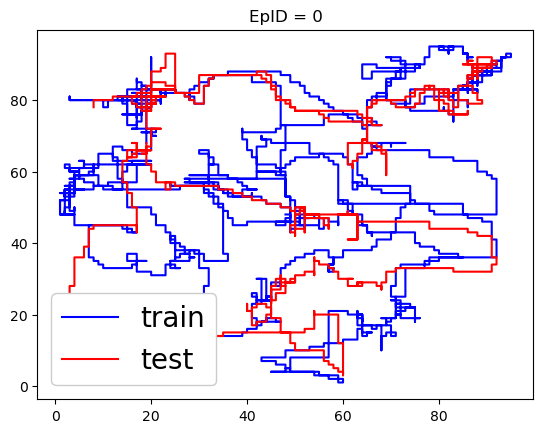

33


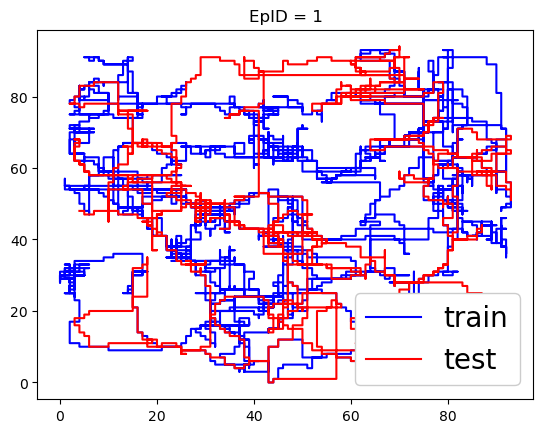

33


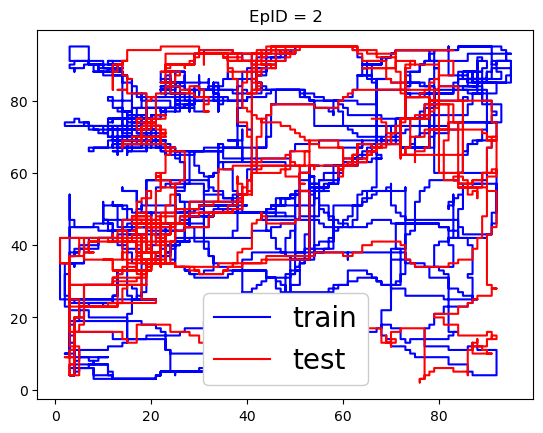

33


C:\Users\ryanb\AppData\Local\Temp\ipykernel_84680\861388429.py:136: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['player_position_x'] = pd.to_numeric(data['player_position_x'])
C:\Users\ryanb\AppData\Local\Temp\ipykernel_84680\861388429.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['player_position_y'] = pd.to_numeric(data['player_position_y'])
C:\Users\ryanb\AppData\Local\Temp\ipykernel_84680\861388429.py:138: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

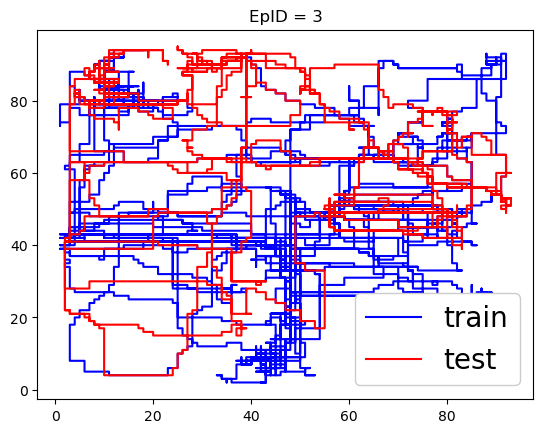

In [2]:
#Merge behavior (scalars.csv) and neural data (hstates.csv)

RunKey = 0 #choose which run/init state to analyze

if RunKey == 0: #path int, jan2025 baseline, fype4js7

    #directoryPath0 = 'C:/Users/chris/Documents/GitHub/Data/fype4js7/'
    directoryPath0 = 'C:/Users/ryanb/Documents/GitHub/GLM_Data/fype4js7/'
    #dirPop = 'C:/Users/ryanb/Documents/GitHub/ForageWorldGLM/population/'
    #dirPop = 'C:/Users/chris/Documents/GitHub/Data/population/'
    dirPop = 'C:/Users/ryanb/Documents/GitHub/GLM_Data/population/'

    file_name1a = directoryPath0 + 'scalars_67584_0.csv'
    file_name2a = directoryPath0 + 'hstates_67584_0.csv'
    
    file_name1b = directoryPath0 + 'scalars_65536_0.csv'
    file_name2b = directoryPath0 + 'hstates_65536_0.csv'
    
    #file_name1c = directoryPath0 + 'scalars_69632_0.csv'
    #file_name2c = directoryPath0 + 'hstates_69632_0.csv'
    
    file_name1c = directoryPath0 + 'scalars_71680_0.csv'
    file_name2c = directoryPath0 + 'hstates_71680_0.csv'
    
    file_name1d = directoryPath0 + 'scalars_61440_0.csv'
    file_name2d = directoryPath0 + 'hstates_61440_0.csv'
    
    file_name1 = [file_name1a,file_name1b,file_name1c,file_name1d]
    file_name2 = [file_name2a,file_name2b,file_name2c,file_name2d]

if RunKey == 1:
        
    #directoryPath0 = 'C:/Users/chris/Documents/GitHub/Data/ivheiklj/'
    directoryPath0 = 'C:/Users/ryanb/Documents/GitHub/GLM_Data/foraging_no_pathint_72h_05_05_25_0/lvheiklj/'
    #dirPop = 'C:/Users/chris/Documents/GitHub/Data/population/'
    dirPop = 'C:/Users/ryanb/Documents/GitHub/GLM_Data/population/'

    file_name1a = directoryPath0 + 'scalars_67584_0.csv'
    file_name2a = directoryPath0 + 'hstates_67584_0.csv'
    
    file_name1b = directoryPath0 + 'scalars_73728_0.csv'
    file_name2b = directoryPath0 + 'hstates_73728_0.csv'
    
    file_name1e = directoryPath0 + 'scalars_69632_0.csv'
    file_name2e = directoryPath0 + 'hstates_69632_0.csv'
    
    file_name1c = directoryPath0 + 'scalars_71680_0.csv'
    file_name2c = directoryPath0 + 'hstates_71680_0.csv'
    
    file_name1d = directoryPath0 + 'scalars_61440_0.csv'
    file_name2d = directoryPath0 + 'hstates_61440_0.csv'
    
    file_name1 = [file_name1a,file_name1b,file_name1c,file_name1d,file_name1e]
    file_name2 = [file_name2a,file_name2b,file_name2c,file_name2d,file_name2e]
    
if RunKey == 2:
        
    #directoryPath0 = 'C:/Users/chris/Documents/GitHub/Data/ivheiklj/'
    #directoryPath0 = 'C:/Users/ryanb/Documents/GitHub/GLM_Data/foraging_no_pathint_72h_05_05_25_0/lvheiklj/'
    directoryPath0 = 'C:/Users/ryanb/Documents/GitHub/GLM_Data/o0z9yo3j_baselineMay/'
    #dirPop = 'C:/Users/chris/Documents/GitHub/Data/population/'
    dirPop = 'C:/Users/ryanb/Documents/GitHub/GLM_Data/population/'

    #file_name1a = directoryPath0 + 'scalars_67584_0.csv'
    #file_name2a = directoryPath0 + 'hstates_67584_0.csv'
    file_name1a = directoryPath0 + 'scalars_75776_0.csv'
    file_name2a = directoryPath0 + 'hstates_75776_0.csv'

    #file_name1b = directoryPath0 + 'scalars_73728_0.csv'
    #file_name2b = directoryPath0 + 'hstates_73728_0.csv'
    file_name1b = directoryPath0 + 'scalars_83968_0.csv'
    file_name2b = directoryPath0 + 'hstates_83968_0.csv'

    file_name1c = directoryPath0 + 'scalars_63488_0.csv'
    file_name2c = directoryPath0 + 'hstates_63488_0.csv'
    
    file_name1d = directoryPath0 + 'scalars_61440_0.csv'
    file_name2d = directoryPath0 + 'hstates_61440_0.csv'
    
    file_name1e = directoryPath0 + 'scalars_90112_0.csv'
    file_name2e = directoryPath0 + 'hstates_90112_0.csv'
    
    file_name1f = directoryPath0 + "scalars_88064_0.csv"
    file_name2f = directoryPath0 + "hstates_88064_0.csv"
    
    file_name1 = [file_name1a,file_name1b,file_name1c,file_name1d,file_name1e,file_name1f]
    file_name2 = [file_name2a,file_name2b,file_name2c,file_name2d,file_name2e,file_name2f]    

x_min, x_max = 0, 95 #arena size in the jax task
y_min, y_max = 0, 95
num_bins_x = 14 # number of bins to coarse-grain the arena for analysis
num_bins_y = 14
numEp = len(file_name1)
cut = 0.7 #test/train cut 70% of data is train if 0.7
start_cut = 250 # initial amount of timesteps to cut, episode transitions have transient activity
numExtraFactors = 0 # food, energy, drink in GLM or not, if == 0 only binary position bin regressors are used
nNeurons = 512 # number of neurons in the LSTM/GRU
countFactor = 1 

ep_idx0 = 2000 #used for slope criteria to omit in goodness of fit criteria below
ep_idx1 = 10000

ep_time_transitions_train = []
ep_time_transitions_test = []
ep_time_transitions_train.append(0)
ep_time_transitions_test.append(0)

# merges several episodes into one long time series and then does test/train divisions per episode
for ep_id in range(numEp):
    

    beh_data = pd.read_csv(file_name1[ep_id], low_memory=False)
    neur_data = pd.read_csv(file_name2[ep_id], low_memory=False, header=None)

    #Ldata = len(beh_data['pred_delta_x'])
    beh_data.drop(beh_data[beh_data['pred_delta_x'] == 'pred_delta_x'].index, inplace = True)
    beh_data.reset_index(drop=True, inplace=True)

    merged_data = pd.concat([beh_data, neur_data], axis=1)
    #print(merged_data)

    #fit just one episode 
    x_no_first_ep = merged_data.copy(deep=True)            
    x_no_first_ep.drop(x_no_first_ep[x_no_first_ep['episode_id'] == merged_data.loc[0,'episode_id']].index, inplace = True)  
    x_no_first_ep.reset_index(drop=True, inplace=True)

    # only look at episodes where one can see the t=0 point for an episode, thus always skip first id in a csv
    data = x_no_first_ep[x_no_first_ep['episode_id'] == x_no_first_ep.loc[0,'episode_id']]  
    #print(final_data)

    neural_idx0 = data.columns.get_loc(0)
    print(neural_idx0) # index of first neural column
    
    # light preprocessing
    #data['time'] = np.arange(len(data))
    data['player_position_x'] = pd.to_numeric(data['player_position_x'])
    data['player_position_y'] = pd.to_numeric(data['player_position_y'])
    data['food'] = pd.to_numeric(data['food'])
    data['drink'] = pd.to_numeric(data['drink'])
    data['energy'] = pd.to_numeric(data['energy'])

    for col in  data.columns[neural_idx0:]:
        data[col] = pd.to_numeric(data[col], errors='coerce')
    
    
    x_t = data['player_position_x']
    y_t = data['player_position_y']
    food_t = data['food']
    energy_t = data['energy']
    drink_t = data['drink']

    #time = data['time']
    
    
    
    num_t_pts = len(x_t)
    ind_cut = int(cut*num_t_pts)
    counts = data.iloc[:, neural_idx0:]
    
    # shows the movement trajectories divided into test/train per episode
    plt.plot(x_t[:ind_cut], y_t[:ind_cut], color='blue', label='train')
    plt.plot(x_t[ind_cut:], y_t[ind_cut:], color='red', label='test')
    titleStr = "EpID = " + str(ep_id)
    plt.title(titleStr)
    plt.legend(fontsize=20,framealpha=1)
    plt.show()

    if ep_id == 0:
        #time_train, time_test = time[start_cut:ind_cut], time[ind_cut:]
        x_train, x_test = x_t[start_cut:ind_cut], x_t[ind_cut:]
        y_train, y_test = y_t[start_cut:ind_cut], y_t[ind_cut:]
        food_train, food_test = food_t[start_cut:ind_cut], food_t[ind_cut:]
        energy_train, energy_test = energy_t[start_cut:ind_cut], energy_t[ind_cut:]
        drink_train, drink_test = drink_t[start_cut:ind_cut], drink_t[ind_cut:]
        counts_train, counts_test = counts.iloc[start_cut:ind_cut,:], counts.iloc[ind_cut:,:]
        
        food_train.reset_index(drop=True, inplace=True)
        energy_train.reset_index(drop=True, inplace=True)
        drink_train.reset_index(drop=True, inplace=True)
        food_test.reset_index(drop=True, inplace=True)
        energy_test.reset_index(drop=True, inplace=True)
        drink_test.reset_index(drop=True, inplace=True)
        
        ep_time_transitions_train.append(len(x_train))
        ep_time_transitions_test.append(len(x_test))
        
    if ep_id > 0:
        #time_train_0, time_test_0 = time[start_cut:ind_cut], time[ind_cut:]
        x_train_0, x_test_0 = x_t[start_cut:ind_cut], x_t[ind_cut:]
        y_train_0, y_test_0 = y_t[start_cut:ind_cut], y_t[ind_cut:]
        food_train_0, food_test_0 = food_t[start_cut:ind_cut], food_t[ind_cut:]
        energy_train_0, energy_test_0 = energy_t[start_cut:ind_cut], energy_t[ind_cut:]
        drink_train_0, drink_test_0 = drink_t[start_cut:ind_cut], drink_t[ind_cut:]    
        counts_train_0, counts_test_0 = counts.iloc[start_cut:ind_cut,:], counts.iloc[ind_cut:,:]
    
        food_train_0.reset_index(drop=True, inplace=True)
        energy_train_0.reset_index(drop=True, inplace=True)
        drink_train_0.reset_index(drop=True, inplace=True)
        food_test_0.reset_index(drop=True, inplace=True)
        energy_test_0.reset_index(drop=True, inplace=True)
        drink_test_0.reset_index(drop=True, inplace=True)
        
        
        #time_train = pd.concat([time_train,time_train_0])
        #time_test = pd.concat([time_test,time_test_0])
        x_train = pd.concat([x_train,x_train_0])
        x_test = pd.concat([x_test,x_test_0])
        y_train = pd.concat([y_train,y_train_0])
        y_test = pd.concat([y_test,y_test_0])
        food_train = pd.concat([food_train,food_train_0])
        food_test = pd.concat([food_test,food_test_0])
        energy_train = pd.concat([energy_train,energy_train_0])
        energy_test = pd.concat([energy_test,energy_test_0])
        drink_train = pd.concat([drink_train,drink_train_0])
        drink_test = pd.concat([drink_test,drink_test_0])
        counts_train = pd.concat([counts_train,counts_train_0])
        counts_test = pd.concat([counts_test,counts_test_0])
        
        #time_train.reset_index(drop=True, inplace=True)
        food_train.reset_index(drop=True, inplace=True)
        energy_train.reset_index(drop=True, inplace=True)
        drink_train.reset_index(drop=True, inplace=True)
        #time_test.reset_index(drop=True, inplace=True)
        food_test.reset_index(drop=True, inplace=True)
        energy_test.reset_index(drop=True, inplace=True)
        drink_test.reset_index(drop=True, inplace=True)

        ep_time_transitions_train.append(len(x_train))
        ep_time_transitions_test.append(len(x_test))


time_train = np.arange(len(x_train))
time_test = np.arange(len(x_test))
dt = time_train[1] - time_train[0]
#HD_train, HD_test = HD_t[:ind_cut], HD_t[ind_cut:]             # FILL IN
#speed_train, speed_test = speed_t[:ind_cut], speed_t[ind_cut:]

 # counts[:ind_cut,:], counts[ind_cut:,:]


In [3]:
#the episode transition timepoints
print(ep_time_transitions_train)
print(ep_time_transitions_test)

[0, 10833, 32403, 53232, 69448]
[0, 4751, 14103, 23137, 30194]


C:\Users\ryanb\AppData\Local\Temp\ipykernel_84680\220307134.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['time'] = np.arange(len(data))
C:\Users\ryanb\AppData\Local\Temp\ipykernel_84680\220307134.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['time'] = np.arange(len(data))


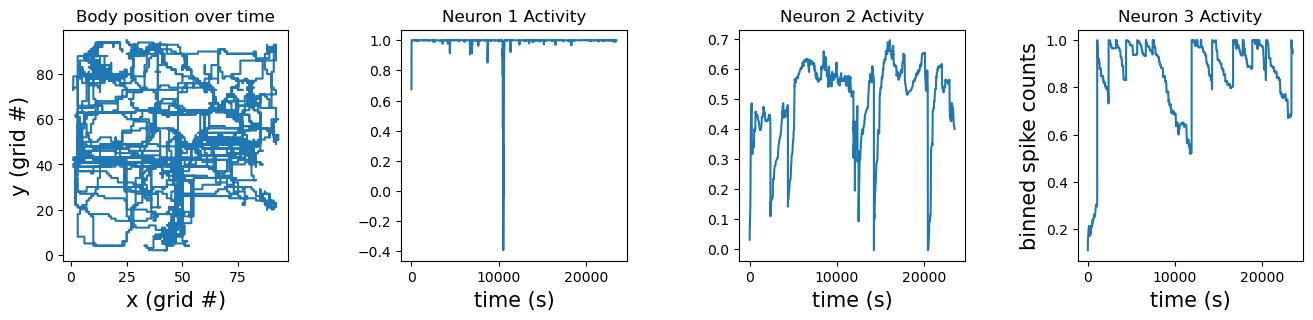

In [4]:
# some plots for the last run in the loop above, just a check

neuron1 = 30    
neuron2 = 21  
neuron3 = 22   

#plot data
data['time'] = np.arange(len(data))
fig, ax = plt.subplots(ncols=4, figsize=(16, 3))

ax[0].plot(data['player_position_x'], data['player_position_y'])
ax[0].set_xlabel('x (grid #)', fontsize=15); ax[0].set_ylabel('y (grid #)', fontsize=15)
ax[0].set_title('Body position over time')

ax[1].plot(data['time'], data[neural_idx0 + neuron1])        # only visualize first neuron
ax[1].set_xlabel('time (s)', fontsize=15); ax[3].set_ylabel('binned spike counts', fontsize=15)
ax[1].set_title('Neuron 1 Activity')

ax[2].plot(data['time'], data[neural_idx0 + neuron2])        # only visualize first neuron
ax[2].set_xlabel('time (s)', fontsize=15); ax[3].set_ylabel('binned spike counts', fontsize=15)
ax[2].set_title('Neuron 2 Activity')

ax[3].plot(data['time'], data[neural_idx0 + neuron3])        # only visualize first neuron
ax[3].set_xlabel('time (s)', fontsize=15); ax[3].set_ylabel('binned spike counts', fontsize=15)
ax[3].set_title('Neuron 3 Activity')

plt.subplots_adjust(wspace=0.5)
plt.show()

In [5]:
# Position bins
bins_x = np.linspace(x_min, x_max, num_bins_x )
bins_y = np.linspace(y_min, y_max, num_bins_y )
print(bins_x)

[ 0.          7.30769231 14.61538462 21.92307692 29.23076923 36.53846154
 43.84615385 51.15384615 58.46153846 65.76923077 73.07692308 80.38461538
 87.69230769 95.        ]


In [6]:
def bin_behavior(x_t, y_t,bins_x,bins_y):
    x_dig = np.digitize(x_t, bins=bins_x) -1; x_dig = np.clip(x_dig, 0, num_bins_x-1)
    y_dig = np.digitize(y_t, bins=bins_y) -1; y_dig = np.clip(y_dig, 0, num_bins_y-1)
    #HD_dig = np.digitize(HD_t, bins=bins_HD) -1; HD_dig = np.clip(HD_dig, 0, num_bins_HD-1) # YOU FILL IN
    #speed_dig = np.digitize(speed_t, bins=bins_speed) - 1; speed_dig = np.clip(speed_dig, 0, num_bins_speed-1)

    return x_dig, y_dig #, HD_dig, speed_dig

In [7]:
xd_train, yd_train = bin_behavior(x_train, y_train,bins_x,bins_y)
xd_test, yd_test = bin_behavior(x_test, y_test,bins_x,bins_y)

print(xd_train.shape)
print('Same shape as before, but this array contains indices that indicate which bin the current value falls in.')
print('For memory reasons, this is better than explicitly storing a time points x num_bins matrix.')

(69448,)
Same shape as before, but this array contains indices that indicate which bin the current value falls in.
For memory reasons, this is better than explicitly storing a time points x num_bins matrix.


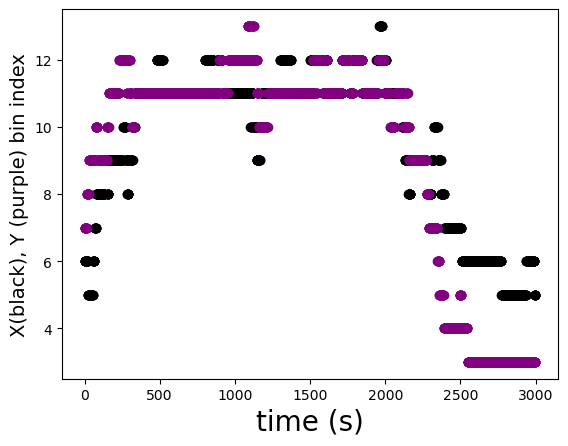

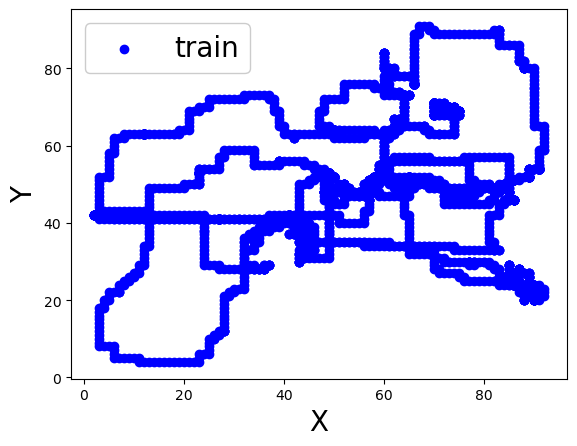

In [8]:
#check how bin position changes over time in a sample of data
ind_max = 3000
plt.scatter(time_train[:ind_max], xd_train[:ind_max],color='k')
plt.scatter(time_train[:ind_max], yd_train[:ind_max],color='purple')
plt.xlabel('time (s)', fontsize=20)
plt.ylabel('X(black), Y (purple) bin index', fontsize=14)
plt.show()

plt.scatter(x_t[:ind_max], y_t[:ind_max], color='blue', label='train')
plt.legend(fontsize=20,framealpha=1)
plt.xlabel('X', fontsize=20)
plt.ylabel('Y', fontsize=20)
plt.show()

In [9]:
#example single neuron fit, code blocks after do the full population

neuronID = 30

pos_bins_train = np.vstack((xd_train, yd_train)).T
pos_bins_test = np.vstack((xd_test, yd_test)).T


pos_factors_train = np.zeros((np.shape(pos_bins_train)[0], num_bins_x*num_bins_y + numExtraFactors))
pos_factors_test = np.zeros((np.shape(pos_bins_test)[0], num_bins_x*num_bins_y + numExtraFactors))

bin_key_x = np.ones((num_bins_x*num_bins_y))*-1
bin_key_y = np.ones((num_bins_x*num_bins_y))*-1

dR_t = np.zeros((np.shape(pos_bins_train)[0],1))

#binarize into factor variable for all possible bins
for t in range(np.shape(pos_bins_train)[0]):
    binID = pos_bins_train[t,0]*num_bins_x + pos_bins_train[t,1]
    pos_factors_train[t,binID] = 1
    bin_key_x[binID] = pos_bins_train[t,0]
    bin_key_y[binID] = pos_bins_train[t,1]

    dXbin =  pos_bins_train[t,0] - (num_bins_x-1)/2
    dYbin =  pos_bins_train[t,1] - (num_bins_y-1)/2
    
    dR_t[t] = int( np.sqrt(dXbin*dXbin + dYbin*dYbin ) )


# if numExtraFactors == 3 then can add energy, drink and food to GLM. For now we only study position, thus == 0
for t in range(np.shape(pos_bins_test)[0]):
    binID = pos_bins_test[t,0]*num_bins_x + pos_bins_test[t,1]
    pos_factors_test[t,binID] = 1

for i in range(numExtraFactors):
    for t in range(np.shape(pos_bins_train)[0]):
        if i == 0:
            pos_factors_train[t,-1*(i+1)] = food_train[t]
        if i == 1:
            pos_factors_train[t,-1*(i+1)] = drink_train[t]
        if i == 2:
            pos_factors_train[t,-1*(i+1)] = energy_train[t]    
            
for i in range(numExtraFactors):
    for t in range(np.shape(pos_bins_test)[0]):
        if i == 0:
            pos_factors_test[t,-1*(i+1)] = food_test[t]
        if i == 1:
            pos_factors_test[t,-1*(i+1)] = drink_test[t]
        if i == 2:
            pos_factors_test[t,-1*(i+1)] = energy_test[t]                
    
#neural data    
counts_train_raw = counts_train.iloc[:, neuronID].to_numpy()
counts_test_raw = counts_test.iloc[:, neuronID].to_numpy()

# shift neural data above 0 and make abs() for GLM machinery, normalize all traces between 0 and 1 for interpretability 
minVal =  np.min(counts_train_raw)
if np.min(counts_test_raw) < minVal:
    minVal = np.min(counts_test_raw)

counts_train_zeroed0 = counts_train_raw - minVal
counts_test_zeroed0 = counts_test_raw - minVal

counts_train_zeroed = countFactor * counts_train_zeroed0 / np.max(counts_train_zeroed0)
counts_test_zeroed = countFactor * counts_test_zeroed0 / np.max(counts_test_zeroed0)

print(counts_train_zeroed)

# Instantiate the single model
model = nmo.glm.GLM()

# define fit the model
model = model.fit(pos_factors_train,counts_train_zeroed)

[0.00967782 0.00981741 0.00983509 ... 0.26446216 0.27297195 0.28587117]


In [10]:
print(food_train[1])

8.0


In [11]:
# model coefficients shape is (num_features, ), num of binX x num of binY
print(f"Model coefficients shape: {model.coef_.shape}")

# model intercept, shape (1,) since there is only one neuron.
print(f"Model intercept shape: {model.intercept_.shape}")

Model coefficients shape: (196,)
Model intercept shape: (1,)


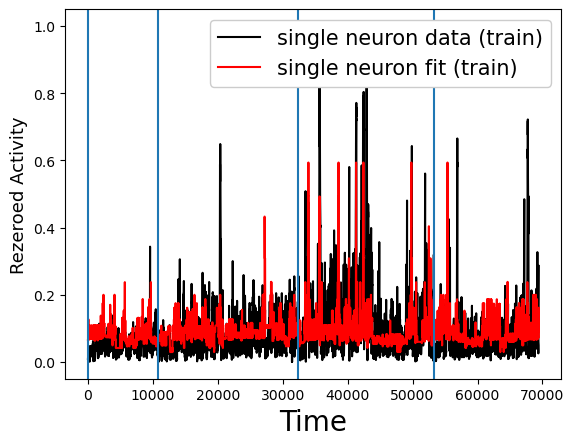

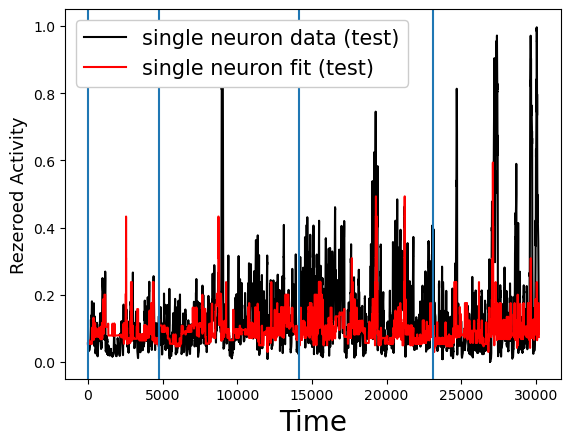

trainLL:  -0.25635293 testLL:  -0.3634166


In [12]:
# predict the rate
predicted_rate_train = model.predict(pos_factors_train)
predicted_rate_test = model.predict(pos_factors_test)
# firing rate has shape: (num_samples,)
predicted_rate_train.shape

#plt.plot(time_train, counts_train_raw,color='gray')
plt.plot(time_train, counts_train_zeroed,color='k',label='single neuron data (train)')
plt.plot(time_train, predicted_rate_train,color='r',label='single neuron fit (train)')
for i in range(len(ep_time_transitions_train)-1):
    plt.axvline(x=ep_time_transitions_train[i])
plt.legend(fontsize=15,framealpha=1)
plt.xlabel('Time', fontsize=20)
plt.ylabel('Rezeroed Activity', fontsize=13)
plt.show()

plt.plot(time_test, counts_test_zeroed,color='k',label='single neuron data (test)')
plt.plot(time_test, predicted_rate_test,color='r',label='single neuron fit (test)')
for i in range(len(ep_time_transitions_test)-1):
    plt.axvline(x=ep_time_transitions_test[i])
plt.legend(fontsize=15,framealpha=1)
plt.xlabel('Time', fontsize=20)
plt.ylabel('Rezeroed Activity', fontsize=13)
plt.show()

# compute the log-likelihood of the model
log_likelihood_train = model.score(pos_factors_train, counts_train_zeroed)
log_likelihood_test = model.score(pos_factors_test, counts_test_zeroed)
print('trainLL: ', log_likelihood_train, 'testLL: ', log_likelihood_test)

In [13]:
# model coefficients shape is (num_features, num_neurons)
print(f"Model coefficients shape: {model.coef_.shape[0]}")

# model intercept, (num_neurons,)
print(f"Model intercept shape: {model.intercept_.shape}")

Model coefficients shape: 196
Model intercept shape: (1,)


In [14]:
#single neuron's regressors vs position

weight_plot = np.ones((num_bins_x, num_bins_y))*-0.05
max_weight_plot = np.ones((num_bins_x, num_bins_y))*-0.05
max_weight_ids = np.ones((num_bins_x, num_bins_y))*-1

print(weight_plot[0,0])
for i in range(model.coef_.shape[0]-numExtraFactors):
    #print(bin_key_x[i], ', ', bin_key_y[i])
    if bin_key_x[i] > -1:
       weight_plot[int(bin_key_x[i]),int(bin_key_y[i])] =  abs(model.coef_[i])
    

-0.05


In [15]:
# Fit full population of neurons now, "Good" plots meet all goodness of fit criteria

# GLM coefficient matricies, will also calculate average and max GLM coefficients
weight_plot = np.ones((num_bins_x, num_bins_y))*-0.05
max_weight_plot = np.ones((num_bins_x, num_bins_y))*-0.05
max_weight_ids = np.ones((num_bins_x, num_bins_y))*-1

GoodWeightList = []
GoodWeightListAbs = []
GoodWeightdX = []
GoodWeightdY = []

#print(weight_plot[0,0])


#num_samples, num_features, num_neurons = 100, 3, 5
alpVal = 0.6 # plotting transparency for later
#population_model = nmo.glm.PopulationGLM()
test_LL = []
train_LL = []

test_cs = []
train_cs = []

test_p = []
train_p = []

train_std_zeroed = []
test_std_zeroed = []
train_std_predicted = []
test_std_predicted = []

counts_train_raw_pop = counts_train.iloc[:, :].to_numpy()
counts_test_raw_pop = counts_test.iloc[:, :].to_numpy()

counts_train_zeroed_pop0 = counts_train.iloc[:, :].to_numpy()
counts_test_zeroed_pop0 = counts_test.iloc[:, :].to_numpy()

counts_train_zeroed_pop = counts_train.iloc[:, :].to_numpy()
counts_test_zeroed_pop = counts_test.iloc[:, :].to_numpy()

for i in range(len(counts_train_raw_pop[1, :])):
    if i < 512:
        minVal =  np.min(counts_train_raw_pop[:, i])
        if np.min(counts_test_raw_pop[:, i]) < minVal:
            minVal = np.min(counts_test_raw_pop[:, i])

    counts_train_zeroed_pop0[:, i] = counts_train_raw_pop[:, i] - minVal
    counts_test_zeroed_pop0[:, i] = counts_test_raw_pop[:, i] - minVal
    
    counts_train_zeroed_pop[:, i] = countFactor * counts_train_zeroed_pop0[:, i] / np.max(counts_train_zeroed_pop0[:, i])
    counts_test_zeroed_pop[:, i] = countFactor * counts_test_zeroed_pop0[:, i] / np.max(counts_test_zeroed_pop0[:, i])

# simulate a design matrix
#X = np.random.normal(size=(num_samples, num_features))
# simulate some counts
#spike_counts = np.random.poisson(size=(num_samples, num_neurons))

# fit the model
GoodCoefSum = 0
GoodIDList = []
GoodCoefList = []

for i in range(nNeurons):
    print("neuron: ", i)
    #i = 88
    Good = 0
    goodct = 0
    intensity = []
    AverageIntensity = 0
    MaxIntensity = 0
    GoodCoefListSum = 0
    
    
    # Instantiate the single model
    #population_model = nmo.glm.GLM(observation_model=nmo.observation_models.GammaObservations(),regularizer="Ridge", regularizer_strength=0.1)
    #population_model = nmo.glm.GLM(observation_model=nmo.observation_models.GammaObservations())
    #population_model = nmo.glm.GLM(observation_model=nmo.observation_models.GammaObservations(),regularizer="Ridge", regularizer_strength=0.000001)
    population_model = nmo.glm.GLM(regularizer="Ridge", regularizer_strength=0.000001)
    #population_model = nmo.glm.GLM(observation_model=nmo.observation_models.GammaObservations(),regularizer="Ridge", regularizer_strength=0.000001)
    # define fit the model
    population_model = population_model.fit(pos_factors_train,counts_train_zeroed_pop[:, i])
    #population_model = population_model.fit(pos_factors_train, counts_train_zeroed_pop)

    # predict the rate of each neuron in the population
    predicted_rate_train_pop = population_model.predict(pos_factors_train)
    predicted_rate_train_pop.shape  # expected shape: (num_samples, num_neurons)

    predicted_rate_test_pop = population_model.predict(pos_factors_test)
    predicted_rate_test_pop.shape  # expected shape: (num_samples, num_neurons)

    # compute the log-likelihood of the model
    log_likelihood_train = population_model.score(pos_factors_train, counts_train_zeroed_pop[:, i])
    log_likelihood_test = population_model.score(pos_factors_test, counts_test_zeroed_pop[:, i])

    cosine_distance_train = cosine(counts_train_zeroed_pop[:, i], predicted_rate_train_pop)
    cosine_similarity_scipy_train = 1 - cosine_distance_train

    cosine_distance_test = cosine(counts_test_zeroed_pop[:, i], predicted_rate_test_pop)
    cosine_similarity_scipy_test = 1 - cosine_distance_test

    correlationcoef_train = np.corrcoef(counts_train_zeroed_pop[:, i], predicted_rate_train_pop)
    correlationcoef_test = np.corrcoef(counts_test_zeroed_pop[:, i], predicted_rate_test_pop)

    standarddev_train_zeroed = np.std(counts_train_zeroed_pop[:, i])
    standarddev_train_predicted = np.std(predicted_rate_train_pop)
    standarddev_test_zeroed = np.std(counts_test_zeroed_pop[:, i])
    standarddev_test_predicted = np.std(predicted_rate_test_pop)
    #
    #slope_segment_time = np.arange(len(counts_train_zeroed_pop[(0+ep_idx0):(0+ep_idx1), i]))
    #standarddev_train_zeroed_seg = np.std(counts_train_zeroed_pop[(ep_time_transitions_train[0]+ep_idx0):(ep_time_transitions_train[0]+ep_idx0+500), i])
    #slope, intercept = np.polyfit(slope_segment_time, counts_train_zeroed_pop[ep_idx0:ep_idx1, i], 1)
    
    #some criteria that require averaging across episodes
    slope_ep1_vec = []
    mean_train_zeroed_ep1_vec = []
    mean_train_predicted_ep1_vec = []
    std_train_zeroed_ep1_vec = []
    std_train_predicted_ep1_vec = []
    err_data_vec = []
    err_model_vec = []
    err_ratio_vec = []
    
    #t_i = np.arange(len(counts_train_zeroed_pop[(ep_time_transitions_train[k]):(ep_time_transitions_train[k+1]), i]))
    t_i = np.arange(len(counts_train_zeroed_pop[:, i]))
    
    for k in range(len(ep_time_transitions_train)-1):
        #plt.axvline(x=ep_time_transitions_train[k])
    
        slope_segment_ep1_k = np.arange(len(counts_train_zeroed_pop[(ep_time_transitions_train[k]):(ep_time_transitions_train[k+1]), i]))
        slope_ep1_k, intercept_ep1_k = np.polyfit(t_i[(ep_time_transitions_train[k]):(ep_time_transitions_train[k+1])], counts_train_zeroed_pop[(ep_time_transitions_train[k]):(ep_time_transitions_train[k+1]), i], 1)

        mean_train_zeroed_ep1_k = np.mean(counts_train_zeroed_pop[(ep_time_transitions_train[k]+2000):(ep_time_transitions_train[k+1]), i])
        mean_train_predicted_ep1_k = np.mean(predicted_rate_train_pop[(ep_time_transitions_train[k]+2000):(ep_time_transitions_train[k+1])])

        std_train_zeroed_ep1_k = np.std(counts_train_zeroed_pop[(ep_time_transitions_train[k]+2000):(ep_time_transitions_train[k+1]), i])
        std_train_predicted_ep1_k = np.std(predicted_rate_train_pop[(ep_time_transitions_train[k]+2000):(ep_time_transitions_train[k+1])])

        #plt.plot(slope_ep1_k*t_i[(ep_time_transitions_train[k]):(ep_time_transitions_train[k+1])] + intercept_ep1_k)
        #plt.plot(counts_train_zeroed_pop[(ep_time_transitions_train[k]):(ep_time_transitions_train[k+1]), i])
        #plt.show()
        err_data_sum_k = []
        err_model_sum_k = []
        for t_i_idx in range(len(t_i[(ep_time_transitions_train[k]):(ep_time_transitions_train[k+1])])):
            err_model_sum_k.append(abs( (t_i[t_i_idx+ep_time_transitions_train[k]]*slope_ep1_k + intercept_ep1_k) - predicted_rate_train_pop[t_i_idx+ep_time_transitions_train[k]]))
            err_data_sum_k.append(abs( (t_i[t_i_idx+ep_time_transitions_train[k]]*slope_ep1_k + intercept_ep1_k) - counts_train_zeroed_pop[t_i_idx+ep_time_transitions_train[k],i]))

        err_data_k = sum(err_data_sum_k) / len(t_i)
        err_model_k = sum(err_model_sum_k) / len(t_i)
        
        err_ratio_k = err_model_k / err_data_k 
        
        slope_ep1_vec.append(slope_ep1_k)
        mean_train_zeroed_ep1_vec.append(mean_train_zeroed_ep1_k)
        mean_train_predicted_ep1_vec.append(mean_train_predicted_ep1_k)
        std_train_zeroed_ep1_vec.append(std_train_zeroed_ep1_k)
        std_train_predicted_ep1_vec.append(std_train_predicted_ep1_k)
        err_data_vec.append(err_data_k)
        err_model_vec.append(err_model_k)
        err_ratio_vec.append(err_ratio_k)
        
        print(k, " ep1 model,data lin fit err, ratio: ", err_model_k, ", ", err_data_k, ", ", err_ratio_k)
    
    slope_ep1 = np.mean(slope_ep1_vec)
    mean_train_zeroed_ep1 = np.mean(mean_train_zeroed_ep1_vec)
    mean_train_predicted_ep1 = np.mean(mean_train_predicted_ep1_vec)
    std_train_zeroed_ep1 = np.mean(std_train_zeroed_ep1_vec)
    std_train_predicted_ep1 = np.mean(std_train_predicted_ep1_vec)
    err_data = np.mean(err_data_vec)
    err_model = np.mean(err_model_vec)
    err_ratio = np.mean(err_ratio_vec)
    
    
    #plt.plot(slope_segment_time, counts_train_zeroed_pop[ep_idx0:ep_idx1, i])
    #plt.plot(slope_segment_time, slope_segment_time*slope + intercept)
    #plt.show()
    #standarddev_train_zeroed = np.std(counts_train_zeroed_pop[ep_idx0:ep_idx1, i])
    
    #for i in range(population_model.coef_.shape[0]-numExtraFactors):
    #    #print(bin_key_x[i], ', ', bin_key_y[i])
    #    if bin_key_x[i] > -1:
    #       weight_plot[int(bin_key_x[i]),int(bin_key_y[i])] =  abs(population_model.coef_[i])

    # cuts on mismatches between mean, std dev, and correlation coefficients
    var_cut = standarddev_train_zeroed/standarddev_train_predicted < 3 and standarddev_train_predicted/standarddev_train_zeroed <3
    var_cut_slope = standarddev_train_zeroed/standarddev_train_predicted < 2.6 and standarddev_train_predicted/standarddev_train_zeroed < 2.6
    var_cut_slope2 = standarddev_train_zeroed/standarddev_train_predicted < 2.6 and standarddev_train_predicted/standarddev_train_zeroed < 2.6
    data_drift_cut = standarddev_train_zeroed < 0.25
    var_noise_cut = True # ((standarddev_train_zeroed_seg >= 1.0e-3 and standarddev_train_zeroed <= 0.21) or (standarddev_train_zeroed_seg >= 8e-3 and standarddev_train_zeroed > 0.21))
    cs_cut = cosine_similarity_scipy_train > 0.55
    pearson_cut = correlationcoef_train[0,1] > 0.35
            
    cut_criteria = var_noise_cut == True and pearson_cut and data_drift_cut == True and cs_cut == True and var_cut == True 
    print("seg_std: ", std_train_zeroed_ep1, "slope: ",slope_ep1, "cs: ", cosine_similarity_scipy_train, "r: ",  correlationcoef_train[0,1], "0top ", standarddev_train_zeroed/standarddev_train_predicted, "pto0 ", standarddev_train_predicted/standarddev_train_zeroed)
    print('ep1 mean model: ', mean_train_predicted_ep1 ,' ep1 mean data: ',mean_train_zeroed_ep1)
    print("ep1 model,data lin fit err: ", err_model, ", ", err_data, " ratio:", err_ratio)
    
    
    test1 = True
    test2 = True
    test3 = True
    test4 = True

    if cut_criteria:
        if abs(slope_ep1) > 5e-6:
            if standarddev_train_zeroed <= 0.10:
                if var_cut_slope2 == True and std_train_zeroed_ep1 >= 1e-3 and standarddev_train_zeroed < 0.23: # and log_likelihood_train < -0.94:
                    Good = 1
                    #print('checks: ', abs(slope),", ",standarddev_train_zeroed/standarddev_train_predicted,", ",standarddev_train_predicted/standarddev_train_zeroed)
            if standarddev_train_zeroed > 0.10:
                if var_cut_slope == True and std_train_zeroed_ep1 >= 1e-3 and standarddev_train_zeroed < 0.25: # and log_likelihood_train < -0.94:
                    Good = 1
        if abs(slope_ep1) <= 5e-6:     
            Good = 1
        if abs(slope_ep1) >= 2.5e-5 and std_train_zeroed_ep1 < 1.0e-3:   # if neuron monotonically ramps with time type 1
            Good = 0    
            test1 = False
            print('test1 fail: ',slope_ep1, ", ", std_train_zeroed_ep1)
        if Good == 1 and ((mean_train_zeroed_ep1/mean_train_predicted_ep1) > 2 or (mean_train_predicted_ep1/mean_train_zeroed_ep1) > 2):
            #excessive mismatch in std dev
            Good = 0
            test2 = False           

        #if Good == 1 and abs(slope_ep1) > 5.0e-5: # if neuron monotonically ramps with time type 2 
        #    Good = 0
            
        if Good == 1 and (std_train_predicted_ep1/std_train_zeroed_ep1) > 3.0:   # if data flatlines but model spiky
            Good = 0
            test4 = False
        if Good == 1 and (((err_ratio > 1.5) and abs(slope_ep1) > 8e-6) or (err_ratio > 2)):  # if neuron monotonically ramps with time type 3
            Good = 0
            test3 = False
        if RunKey == 2: 
            #badlist_manual = [28,29,77,88, 96, 139, 143, 158, 168, 186, 209, 244, 276, 281, 329, 330, 351, 353,462,485]    
            badlist_manual = [] # temp
        if RunKey == 2 and (i in badlist_manual): #can manually omit monotonically time-ramping neurons too, automatic cuts get most things
            Good = 0
            
    print ("cut_criteria", cut_criteria, ", ","vc=",var_cut,", ","vcs=",var_cut_slope,", ","vcs2=",var_cut_slope2, "dc=",data_drift_cut,", ","vnc=",var_noise_cut,"test1,2,3,4=",[test1,test2,test3,test4]," good=",Good)         
    train_LL.append(log_likelihood_train)
    test_LL.append(log_likelihood_test)
    
    print("ep 1 means: ", mean_train_zeroed_ep1, " ", mean_train_predicted_ep1, (mean_train_zeroed_ep1/mean_train_predicted_ep1), (mean_train_predicted_ep1/mean_train_zeroed_ep1))
    print("ep 1 std devs: ", std_train_zeroed_ep1, " ", std_train_predicted_ep1, (std_train_zeroed_ep1/std_train_predicted_ep1), (std_train_predicted_ep1/std_train_zeroed_ep1))
    train_cs.append(cosine_similarity_scipy_train)
    test_cs.append(cosine_similarity_scipy_test)

    train_p.append(correlationcoef_train[0,1])
    test_p.append(correlationcoef_test[0,1])

    train_std_zeroed.append(standarddev_train_zeroed)
    test_std_zeroed.append(standarddev_test_zeroed)
    train_std_predicted.append(standarddev_train_predicted)
    test_std_predicted.append(standarddev_test_predicted)


    
#for i in range(predicted_rate.shape[1]):
    #plt.plot(time_train, counts_train_raw,color='gray')
    plt.plot(time_train, counts_train_zeroed_pop[:, i],color='k',label='single neuron data (train)',alpha=alpVal)
    plt.plot(time_train, predicted_rate_train_pop,color='r',label='single neuron fit (train)',alpha=alpVal)
    for k in range(len(ep_time_transitions_train)-1):
        plt.axvline(x=ep_time_transitions_train[k])
    plt.legend(fontsize=10,framealpha=1,bbox_to_anchor=(1.1, -0.25), loc="lower right")
    plt.xlabel('Time', fontsize=20)
    plt.ylabel('Rezeroed Activity', fontsize=13)
    #plt.xlim(-2.7,0)
    plt.ylim(0,1.1)
    titleTrain = "Neuron" + str(i) +' LL=' + f"{log_likelihood_train:.{3}g}"+' cs=' + f"{cosine_similarity_scipy_train:.{3}g}" + ' r=' + f"{correlationcoef_train[0,1]:.{3}g}" + ' std0=' + f"{standarddev_train_zeroed:.{3}g}"+ ' stdp=' + f"{standarddev_train_predicted:.{3}g}"+ ' sg=' + f"{std_train_zeroed_ep1:.{2}g}" + ' sl=' f"{slope_ep1:.{2}g}"+' good=' +str(Good)
    plt.title(titleTrain)
    
    filenameTrain = dirPop + 'train/train' + str(i) + '.png'
    plt.savefig(filenameTrain, bbox_inches="tight")
    #plt.show()
    plt.close()

    plt.plot(time_test, counts_test_zeroed_pop[:, i ],color='k',label='single neuron data (test)',alpha=alpVal)
    plt.plot(time_test, predicted_rate_test_pop,color ='r',label='single neuron fit (test)',alpha=alpVal)
    for k in range(len(ep_time_transitions_test)-1):
        plt.axvline(x=ep_time_transitions_test[k])
    plt.legend(fontsize=10,framealpha=1,bbox_to_anchor=(1.1, -0.25), loc="lower right")
    plt.xlabel('Time', fontsize=20)
    plt.ylabel('Rezeroed Activity', fontsize=13)
    plt.ylim(0,1.1)
    titleTest = "Neuron" + str(i) +' LL=' + f"{log_likelihood_test:.{3}g}"+' cs=' + f"{cosine_similarity_scipy_test:.{3}g}" + ' r=' + f"{correlationcoef_test[0,1]:.{3}g}"+ ' std0=' + f"{standarddev_test_zeroed:.{3}g}"+ ' stdp=' + f"{standarddev_test_predicted:.{3}g}"+ ' sg=' + f"{std_train_zeroed_ep1:.{2}g}"+  ' sl=' + f"{slope_ep1:.{2}g}" + ' good=' +str(Good) 
    plt.title(titleTest)
    filenameTest = dirPop + 'test/test' + str(i) + '.png'
    plt.savefig(filenameTest, bbox_inches="tight")
    #plt.show()
    plt.close()

    #zoomed in, TBD
    zoomN0 = 2500
    zoomN1 = 6500
    plt.plot(time_train[zoomN0:zoomN1], counts_train_zeroed_pop[zoomN0:zoomN1, i],color='k',label='single neuron data (train)',alpha=alpVal)
    plt.plot(time_train[zoomN0:zoomN1], predicted_rate_train_pop[zoomN0:zoomN1],color='r',label='single neuron fit (train)',alpha=alpVal)
    #for k in range(len(ep_time_transitions_train)-1):
    #    plt.axvline(x=ep_time_transitions_train[k])
    plt.legend(fontsize=10,framealpha=1,bbox_to_anchor=(1.1, -0.25), loc="lower right")
    plt.xlabel('Time', fontsize=20)
    plt.ylabel('Rezeroed Activity', fontsize=13)
    plt.ylim(0,1.1)
    titleTrain = "Neuron" + str(i) +' LL=' + f"{log_likelihood_train:.{3}g}"+' cs=' + f"{cosine_similarity_scipy_train:.{3}g}" + ' r=' + f"{correlationcoef_train[0,1]:.{3}g}"+ ' std0=' + f"{standarddev_train_zeroed:.{3}g}"+ ' stdp=' + f"{standarddev_train_predicted:.{3}g}"+ ' sg=' + f"{std_train_zeroed_ep1:.{2}g}"+ ' sl=' + f"{slope_ep1:.{2}g}"+ "sl0="+ f"{slope_ep1:.{2}g}" +' good=' +str(Good)
    plt.title(titleTrain)
    #plt.legend()
    filenameTrain = dirPop + 'train/zoom_train' + str(i) + '.png'
    plt.savefig(filenameTrain, bbox_inches="tight")
    #plt.show()
    plt.close()

    plt.plot(time_test[zoomN0:zoomN1], counts_test_zeroed_pop[zoomN0:zoomN1, i ],color='k',label='single neuron data (test)',alpha=alpVal)
    plt.plot(time_test[zoomN0:zoomN1], predicted_rate_test_pop[zoomN0:zoomN1],color ='r',label='single neuron fit (test)',alpha=alpVal)
    #for k in range(len(ep_time_transitions_test)-1):
    #    plt.axvline(x=ep_time_transitions_test[k])
    plt.legend(fontsize=10,framealpha=1,bbox_to_anchor=(1.1, -0.25), loc="lower right")
    plt.xlabel('Time', fontsize=20)
    plt.ylabel('Rezeroed Activity', fontsize=13)
    plt.ylim(0,1.1)
    titleTest = "Neuron" + str(i) +' LL=' + f"{log_likelihood_test:.{3}g}"+' cs=' + f"{cosine_similarity_scipy_test:.{3}g}" + ' r=' + f"{correlationcoef_test[0,1]:.{3}g}"+ ' std0=' + f"{standarddev_test_zeroed:.{3}g}"+ ' stdp=' + f"{standarddev_test_predicted:.{3}g}"+ ' sl=' + f"{slope_ep1:.{2}g}"+ ' good=' +str(Good)
    plt.title(titleTest)
    filenameTest = dirPop + 'test/zoom_test' + str(i) + '.png'
    plt.savefig(filenameTest, bbox_inches="tight")
    #plt.show()
    plt.close()
    
    #weight_plot = np.ones((num_bins_x, num_bins_y))*-0.5
    binHist = []
    #print(weight_plot[0,0])
    for j in range(population_model.coef_.shape[0]-numExtraFactors):
        #print(bin_key_x[i], ', ', bin_key_y[i])
        if bin_key_x[j] > -1:
           weight_plot[int(bin_key_x[j]),int(bin_key_y[j])] =  abs(population_model.coef_[j])
           if Good == 1:
               if max_weight_plot[int(bin_key_x[j]),int(bin_key_y[j])] < abs(population_model.coef_[j]):
                    max_weight_plot[int(bin_key_x[j]),int(bin_key_y[j])] = abs(population_model.coef_[j])
                    max_weight_ids[int(bin_key_x[j]),int(bin_key_y[j])] = i
               GoodWeightList.append(population_model.coef_[j])
               GoodWeightListAbs.append(abs(population_model.coef_[j]))
               GoodWeightdX.append(int(bin_key_x[j]) - (num_bins_x-1)/2)
               GoodWeightdY.append(int(bin_key_y[j]) - (num_bins_y-1)/2)
        binHist.append(abs(population_model.coef_[j]))
    
    
    ax = sns.heatmap(weight_plot,cmap='viridis')
    ax.invert_yaxis()
    ax.set_xlabel("X Bin ID")
    ax.set_ylabel("Y Bin ID")
    titleCoeff = "Neuron" + str(i) + " Activity Coeff Per Bin"
    ax.set_title(titleCoeff)
    filenameCoeffs = dirPop + 'coeff/coeff' + str(i) + '.png'
    ax.figure.savefig(filenameCoeffs)    
    plt.close(ax.figure)
    
    plt.plot(binHist)
    #for k in range(len(ep_time_transitions_test)-1):
    #    plt.axvline(x=ep_time_transitions_test[k])
    #plt.legend(fontsize=15,framealpha=1)
    plt.xlabel('Position BinID', fontsize=18)
    plt.ylabel('GLM Pos. Coeff Value', fontsize=18)
    titleTest = "Neuron" + str(i) +' LL=' + f"{log_likelihood_test:.{3}g}"+' cs=' + f"{cosine_similarity_scipy_test:.{3}g}" + ' r=' + f"{correlationcoef_test[0,1]:.{3}g}"+ ' std0=' + f"{standarddev_test_zeroed:.{3}g}"+ ' stdp=' + f"{standarddev_test_predicted:.{3}g}" + ' sl=' + f"{slope_ep1:.{2}g}"+ ' good=' +str(Good)
    plt.title(titleTest)
    filenameTest = dirPop + 'coeff/hist' + str(i) + '.png'
    plt.savefig(filenameTest)
    #plt.show()
    plt.close()

    if Good == 1:
        GoodIDList.append(i)
        GoodCoefList.append(weight_plot)
        #goodct += 1
        GoodCoefSum = GoodCoefSum + (weight_plot)

        sub_idx0 = 11000
        sub_idx1 = 19000
        fig, ax1 = plt.subplots()
        ax2 = ax1.twinx()
        ax1.plot(time_train[sub_idx0:sub_idx1], counts_train_zeroed_pop[sub_idx0:sub_idx1, i],color='k',label='single neuron data (train)',alpha=alpVal-0.1)
        ax1.plot(time_train[sub_idx0:sub_idx1], predicted_rate_train_pop[sub_idx0:sub_idx1],color='r',label='single neuron fit (train)',alpha=alpVal-0.1)
        ax2.plot(time_train[sub_idx0:sub_idx1], dR_t[sub_idx0:sub_idx1] ,color='b', label='radial distance',alpha=alpVal-0.1)
        #for i in range(len(ep_time_transitions_train)-1):
        #    plt.axvline(x=ep_time_transitions_train[i])
        lines, label1 = ax1.get_legend_handles_labels()
        lines2, label2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, label1 + label2, fontsize=10,framealpha=1,bbox_to_anchor=(1.1, -0.3), loc="lower right")
        #plt.legend(fontsize=10,framealpha=1,bbox_to_anchor=(1.1, -0.25), loc="lower right")
        ax1.set_xlabel('Time', fontsize=20)
        ax1.set_ylabel('Rezeroed Activity', fontsize=13)
        ax2.set_ylabel('Radial Dist. From Origin (bins)', fontsize=13)
        ax2.tick_params(axis='y',labelcolor='b')
        ax2.set_ylim(0,7)
        titleTrain = "Neuron" + str(i) +' LL=' + f"{log_likelihood_train:.{3}g}"+' cs=' + f"{cosine_similarity_scipy_train:.{3}g}" + ' r=' + f"{correlationcoef_train[0,1]:.{3}g}"+ ' std0=' + f"{standarddev_train_zeroed:.{3}g}"+ ' stdp=' + f"{standarddev_train_predicted:.{3}g}"+ ' sg=' + f"{std_train_zeroed_ep1:.{2}g}"+ ' sl=' + f"{slope_ep1:.{2}g}"+ ' good=' +str(Good)
        plt.title(titleTrain)
        #plt.legend()
        filenameTrain = dirPop + 'train/dR_train' + str(i) + '.png'
        plt.savefig(filenameTrain, bbox_inches="tight")
        #plt.show()
        plt.close()

    #if i == (nNeurons - 1):    
        #if GoodCoefListMax < weight_plot:
        #    GoodCoefListMax = weight_plot
        
    
    
#print(GoodIDList)
#print(GoodCoefList)
#iterate GoodCoefList to create avg and max of coef intensity

    
    
#plt.imshow(weight_plot, cmap='hot', interpolation='none')
#plt.show()    

#ax = sns.heatmap(weight_plot)
#ax.invert_yaxis()
#ax.figure.savefig() 

neuron:  0
0  ep1 model,data lin fit err, ratio:  0.016527187 ,  0.01005432824375976 ,  1.6437882
1  ep1 model,data lin fit err, ratio:  0.07484335 ,  0.029024865726219515 ,  2.5785942
2  ep1 model,data lin fit err, ratio:  0.026346948 ,  0.025527665184017962 ,  1.0320939
3  ep1 model,data lin fit err, ratio:  0.05122116 ,  0.011449237261383118 ,  4.4737616
seg_std:  0.090596095349707 slope:  4.097132811592677e-06 cs:  0.9176087273543198 r:  0.5924978165065148 0top  1.6870805 pto0  0.59273994
ep1 mean model:  0.47624832  ep1 mean data:  0.44750133022522554
ep1 model,data lin fit err:  0.042234663 ,  0.01901402410384509  ratio: 2.4320595
cut_criteria False ,  vc= True ,  vcs= True ,  vcs2= True dc= False ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 0
ep 1 means:  0.44750133022522554   0.47624832 0.9396386459574189 1.0642389010948752
ep 1 std devs:  0.090596095349707   0.13279837 0.6822078676574997 1.46582888795127
neuron:  1
0  ep1 model,data lin fit err, ratio:  0.04158661

neuron:  9
0  ep1 model,data lin fit err, ratio:  0.005707228 ,  0.005370722755048069 ,  1.0626556
1  ep1 model,data lin fit err, ratio:  0.0064688628 ,  0.0019942225934167345 ,  3.2438016
2  ep1 model,data lin fit err, ratio:  0.00609264 ,  0.0005360299973152945 ,  11.36623
3  ep1 model,data lin fit err, ratio:  0.025296476 ,  0.030545480038157196 ,  0.8281577
seg_std:  0.012221583997191594 slope:  -1.058934241446542e-05 cs:  0.47923517425617923 r:  0.4347836187376361 0top  2.3388295 pto0  0.4275643
ep1 mean model:  0.02079267  ep1 mean data:  0.0032725051053909275
ep1 model,data lin fit err:  0.010891302 ,  0.009611613845984324  ratio: 4.1252112
cut_criteria False ,  vc= True ,  vcs= True ,  vcs2= True dc= True ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 0
ep 1 means:  0.0032725051053909275   0.02079267 0.15738743601223718 6.353747321496794
ep 1 std devs:  0.012221583997191594   0.037492156 0.32597709205681713 3.067700229148931
neuron:  10
0  ep1 model,data lin fit err,

neuron:  18
0  ep1 model,data lin fit err, ratio:  0.024674615 ,  0.00831137815797195 ,  2.9687755
1  ep1 model,data lin fit err, ratio:  0.0355997 ,  0.031173666642192326 ,  1.1419799
2  ep1 model,data lin fit err, ratio:  0.034683436 ,  0.019810988949832367 ,  1.750717
3  ep1 model,data lin fit err, ratio:  0.045228332 ,  0.018611755742305433 ,  2.430095
seg_std:  0.1087609509681016 slope:  3.8490612070656344e-05 cs:  0.9725375365175472 r:  0.49376409381642666 0top  2.0380027 pto0  0.49067646
ep1 mean model:  0.82762367  ep1 mean data:  0.8562311025298175
ep1 model,data lin fit err:  0.03504652 ,  0.01947694737307552  ratio: 2.072892
cut_criteria True ,  vc= True ,  vcs= True ,  vcs2= True dc= True ,  vnc= True test1,2,3,4= [True, True, False, True]  good= 0
ep 1 means:  0.8562311025298175   0.82762367 1.0345657554216021 0.9665891169889766
ep 1 std devs:  0.1087609509681016   0.09422044 1.154324415219357 0.8663075880708712
neuron:  19
0  ep1 model,data lin fit err, ratio:  0.00751681

neuron:  27
0  ep1 model,data lin fit err, ratio:  0.020110605 ,  0.017210079467382525 ,  1.1685364
1  ep1 model,data lin fit err, ratio:  0.0054738102 ,  0.0031550227237306314 ,  1.7349511
2  ep1 model,data lin fit err, ratio:  0.0157797 ,  0.015624627791382139 ,  1.0099249
3  ep1 model,data lin fit err, ratio:  0.0046591028 ,  0.004434181059906884 ,  1.0507245
seg_std:  0.014224884967646926 slope:  1.666710950862296e-05 cs:  0.9946813098246031 r:  0.5186802694477715 0top  1.895918 pto0  0.52744895
ep1 mean model:  0.97321177  ep1 mean data:  0.9872522394596015
ep1 model,data lin fit err:  0.011505804 ,  0.010105977760600543  ratio: 1.2410343
cut_criteria True ,  vc= True ,  vcs= True ,  vcs2= True dc= True ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 1
ep 1 means:  0.9872522394596015   0.97321177 1.0144269466020286 0.9857782301127215
ep 1 std devs:  0.014224884967646926   0.040162347 0.35418460172591143 2.823386435003343
neuron:  28
0  ep1 model,data lin fit err, ratio: 

neuron:  36
0  ep1 model,data lin fit err, ratio:  0.008097652 ,  0.007616795448638299 ,  1.0631311
1  ep1 model,data lin fit err, ratio:  0.023610076 ,  0.03899334699928645 ,  0.60548985
2  ep1 model,data lin fit err, ratio:  0.0179485 ,  0.012829116260829544 ,  1.3990442
3  ep1 model,data lin fit err, ratio:  0.015693545 ,  0.03317274661802241 ,  0.47308552
seg_std:  0.08733132604604543 slope:  5.523309156350028e-07 cs:  0.7623867670210145 r:  0.4953436611917233 0top  2.024254 pto0  0.49400914
ep1 mean model:  0.1366545  ep1 mean data:  0.11783225818632663
ep1 model,data lin fit err:  0.016337443 ,  0.02315300133169417  ratio: 0.8851876
cut_criteria True ,  vc= True ,  vcs= True ,  vcs2= True dc= True ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 1
ep 1 means:  0.11783225818632663   0.1366545 0.8622640415721718 1.159737565046425
ep 1 std devs:  0.08733132604604543   0.066157736 1.3200470795874968 0.7575487385741508
neuron:  37
0  ep1 model,data lin fit err, ratio:  0.0083

...

neuron:  472
0  ep1 model,data lin fit err, ratio:  0.020727595 ,  0.010179054648101895 ,  2.0362985
1  ep1 model,data lin fit err, ratio:  0.028805377 ,  0.0231256129421946 ,  1.2456049
2  ep1 model,data lin fit err, ratio:  0.036753476 ,  0.025231052496306507 ,  1.4566762
3  ep1 model,data lin fit err, ratio:  0.032449782 ,  0.016825539008372584 ,  1.9286029
seg_std:  0.0748550092297324 slope:  2.920259034392688e-05 cs:  0.9735804643442088 r:  0.47882080795786325 0top  2.0995054 pto0  0.47630265
ep1 mean model:  0.74829865  ep1 mean data:  0.7725620238660308
ep1 model,data lin fit err:  0.029684057 ,  0.018840314773743896  ratio: 1.6667957
cut_criteria True ,  vc= True ,  vcs= True ,  vcs2= True dc= True ,  vnc= True test1,2,3,4= [True, True, False, True]  good= 0
ep 1 means:  0.7725620238660308   0.74829865 1.0324247264217166 0.9685936169563688
ep 1 std devs:  0.0748550092297324   0.07841055 0.9546548050095479 1.0474990486116065
neuron:  473
0  ep1 model,data lin fit err, ratio:  0.

neuron:  481
0  ep1 model,data lin fit err, ratio:  0.003697981 ,  0.005401332119031191 ,  0.68464243
1  ep1 model,data lin fit err, ratio:  0.009238459 ,  0.014622998270461469 ,  0.631776
2  ep1 model,data lin fit err, ratio:  0.0155562805 ,  0.02876543004076169 ,  0.54079777
3  ep1 model,data lin fit err, ratio:  0.009661274 ,  0.022585673575557772 ,  0.42776117
seg_std:  0.12598917453607145 slope:  -2.550487348917791e-07 cs:  0.5316315028368126 r:  0.4114637717918213 0top  2.3680065 pto0  0.42229614
ep1 mean model:  0.05175415  ep1 mean data:  0.051954586902399014
ep1 model,data lin fit err:  0.009538499 ,  0.01784385850145303  ratio: 0.5712443
cut_criteria False ,  vc= True ,  vcs= True ,  vcs2= True dc= True ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 0
ep 1 means:  0.051954586902399014   0.05175415 1.0038728558129633 0.996142085334276
ep 1 std devs:  0.12598917453607145   0.051376317 2.452281180073121 0.40778358049878377
neuron:  482
0  ep1 model,data lin fit err, r

neuron:  490
0  ep1 model,data lin fit err, ratio:  0.012115008 ,  0.01519911193231205 ,  0.7970866
1  ep1 model,data lin fit err, ratio:  0.020779341 ,  0.033466213661209845 ,  0.6209051
2  ep1 model,data lin fit err, ratio:  0.02315746 ,  0.03182699298177302 ,  0.72760445
3  ep1 model,data lin fit err, ratio:  0.014077879 ,  0.029339769269362333 ,  0.4798224
seg_std:  0.14491663990446493 slope:  1.3667227936081628e-05 cs:  0.9539099909041194 r:  0.5121239803864095 0top  1.9829392 pto0  0.5043019
ep1 mean model:  0.4245602  ep1 mean data:  0.4309137931246611
ep1 model,data lin fit err:  0.017532423 ,  0.027458021961164314  ratio: 0.6563546
cut_criteria True ,  vc= True ,  vcs= True ,  vcs2= True dc= True ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 1
ep 1 means:  0.4309137931246611   0.4245602 1.0149651428429889 0.98525551054781
ep 1 std devs:  0.14491663990446493   0.0731995 1.9797489562115027 0.5051145484191213
neuron:  491
0  ep1 model,data lin fit err, ratio:  0.00021

neuron:  499
0  ep1 model,data lin fit err, ratio:  0.011099722 ,  0.0012437090731394383 ,  8.924693
1  ep1 model,data lin fit err, ratio:  0.03501338 ,  0.004241756863774489 ,  8.254453
2  ep1 model,data lin fit err, ratio:  0.031719875 ,  0.004092745945401251 ,  7.750267
3  ep1 model,data lin fit err, ratio:  0.029661775 ,  0.006926474557144558 ,  4.282377
seg_std:  0.13629605668954345 slope:  -2.971461336077174e-05 cs:  0.9839725517469615 r:  0.5109261619902861 0top  1.9525497 pto0  0.5121509
ep1 mean model:  0.7553537  ep1 mean data:  0.7439259401884064
ep1 model,data lin fit err:  0.02687369 ,  0.004126171609864934  ratio: 7.3029475
cut_criteria True ,  vc= True ,  vcs= True ,  vcs2= True dc= True ,  vnc= True test1,2,3,4= [True, True, False, True]  good= 0
ep 1 means:  0.7439259401884064   0.7553537 0.9848709959733998 1.0153614068121148
ep 1 std devs:  0.13629605668954345   0.0752122 1.8121534978940887 0.5518296331751721
neuron:  500
0  ep1 model,data lin fit err, ratio:  0.01043

neuron:  508
0  ep1 model,data lin fit err, ratio:  0.0075229 ,  0.00671069587053056 ,  1.1210313
1  ep1 model,data lin fit err, ratio:  0.0030039647 ,  0.00508057222657315 ,  0.591265
2  ep1 model,data lin fit err, ratio:  0.005176939 ,  0.004063770854582935 ,  1.2739251
3  ep1 model,data lin fit err, ratio:  0.0047443477 ,  0.0010441784370459949 ,  4.5436177
seg_std:  0.026383607841703988 slope:  2.9224786034163857e-06 cs:  0.9991598299225605 r:  0.4728863503342784 0top  2.110275 pto0  0.47387186
ep1 mean model:  0.958659  ep1 mean data:  0.9558664492843347
ep1 model,data lin fit err:  0.005112038 ,  0.004224804347183161  ratio: 1.8824598
cut_criteria True ,  vc= True ,  vcs= True ,  vcs2= True dc= True ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 1
ep 1 means:  0.9558664492843347   0.958659 0.9970870309677206 1.0029214792107488
ep 1 std devs:  0.026383607841703988   0.01907504 1.3831482478698485 0.7229882997285899
neuron:  509
0  ep1 model,data lin fit err, ratio:  0.00

In [16]:
print(std_train_zeroed_ep1_vec)

[0.15547348432367533, 0.15922424808954475, 0.18554246979320613, 0.1860203792313]


In [17]:
# train vs test LL, gives an idea of overfitting, currently the code fits 5 episodes with 1 model

plt.scatter(train_LL,test_LL)
plt.xlabel('Training LL', fontsize=20)
plt.ylabel('Test LL', fontsize=20)
#plt.xlim(-2.7,0)
#plt.ylim(-2.7,0)
filenameTest = dirPop + 'LL' + str(i) + '.png'
plt.savefig(filenameTest)
#plt.show()
plt.close()

In [18]:
print(len(GoodIDList))

190


In [19]:
print(GoodIDList)

[3, 4, 5, 6, 8, 10, 12, 19, 21, 24, 25, 27, 30, 35, 36, 38, 40, 46, 47, 48, 49, 50, 51, 55, 58, 62, 65, 67, 68, 69, 72, 75, 76, 77, 79, 82, 83, 84, 86, 87, 88, 90, 92, 95, 96, 97, 98, 100, 101, 105, 106, 107, 110, 113, 117, 125, 127, 130, 133, 136, 137, 139, 146, 153, 157, 158, 163, 167, 168, 169, 172, 173, 176, 178, 179, 182, 185, 188, 190, 192, 193, 195, 198, 199, 202, 206, 212, 216, 217, 219, 229, 231, 232, 234, 239, 240, 242, 243, 251, 254, 258, 262, 263, 269, 276, 277, 280, 281, 285, 287, 288, 293, 294, 303, 304, 306, 309, 310, 312, 325, 326, 329, 330, 336, 337, 339, 340, 345, 347, 348, 349, 352, 353, 355, 357, 362, 373, 374, 377, 383, 392, 393, 395, 399, 402, 403, 405, 406, 407, 411, 413, 416, 417, 419, 421, 422, 423, 426, 430, 432, 433, 437, 439, 440, 444, 447, 448, 451, 452, 453, 455, 456, 459, 461, 465, 475, 477, 480, 482, 484, 486, 487, 489, 490, 493, 494, 500, 508, 509, 511]


In [20]:
AverageIntensity = GoodCoefSum/len(GoodIDList)

In [21]:
ax = sns.heatmap(max_weight_plot,cmap='inferno') #, vmin=3, vmax=0)
ax.invert_yaxis()
ax.set_xlabel("X Bin ID")
ax.set_ylabel("Y Bin ID")
titleCoeff =  "Max Activity Coeff Per Bin Max"
ax.set_title(titleCoeff)
filenameCoeffs = dirPop + 'coeff/coeff' + '_Max.png'
ax.figure.savefig(filenameCoeffs)    
plt.close(ax.figure)

for i in range(num_bins_x):
    for j in range(num_bins_y):
        print(AverageIntensity[i,j])
        if AverageIntensity[i,j] == -0.049999999999999885:            
            AverageIntensity[i,j] = math.nan
        

#MaxIntensity = GoodCoefListMax
#  intensity.append(weight_plot[GoodIDList])
ax = sns.heatmap(AverageIntensity,cmap='inferno', vmin=0.5, vmax=0.1)
ax.invert_yaxis()
ax.set_xlabel("X Bin ID")
ax.set_ylabel("Y Bin ID")
titleCoeff = "Ave. Activity Coeff Per Bin Avg"
ax.set_title(titleCoeff)
filenameCoeffs = dirPop + 'coeff/coeff' + '_Avg.png'
ax.figure.savefig(filenameCoeffs)    
plt.close(ax.figure)
        
#if GoodCoefListMax < weight_plot:
#    GoodCoefListMax = weight_plot
#AverageIntensity = GoodCoefSum/len(GoodIDList)
#MaxIntensity = GoodCoefListMax
#        intensity.append(weight_plot[GoodIDList])
ax = sns.heatmap(max_weight_ids,cmap='viridis', annot=True,fmt='.0f')
ax.invert_yaxis()
ax.set_xlabel("X Bin ID")
ax.set_ylabel("Y Bin ID")
titleCoeff = "neuronID of Max Activity Coeff Per Bin Max"
ax.set_title(titleCoeff)
filenameCoeffs = dirPop + 'coeff/coeff' + '_MaxID.png'
ax.figure.savefig(filenameCoeffs)    
plt.close(ax.figure)

0.2572658406922863
0.25184632208620317
0.25871781620601386
0.23094053448416832
0.21745168558493452
0.260105932328703
0.14942314333947204
0.30113208940816355
0.2347204865875124
0.412141371090394
0.24924462520590934
0.2320020113379494
0.3091980228442576
0.05380132077897495
0.4232930368682566
0.21670198850027333
0.14863374544564928
0.17468002037739527
0.13462772759942854
0.2223907055840276
0.16004456564589514
0.16456027459874015
0.1892497329006131
0.2366407971250163
0.16979137210536896
0.2531494719950531
0.21555472552518998
-0.05
0.27581766274632075
0.23928373840596912
0.19760818767678612
0.17161129243475826
0.14623334451676592
0.12550623521368068
0.23888632299893192
0.1490949734990289
0.23948053937668815
0.24389969409974965
0.18956389191842296
0.16743375502103988
0.24711360991809908
-0.05
0.269698614359674
0.16237193508331027
0.21713696686079187
0.16037089123381423
0.2637588070252126
0.18060112597047823
0.13674847065642673
0.13035621447304852
0.16929808730109422
0.25064525735644183
0.261

In [22]:
print(err_data)

0.0346487495435614


In [23]:
print(len(GoodIDList))

190


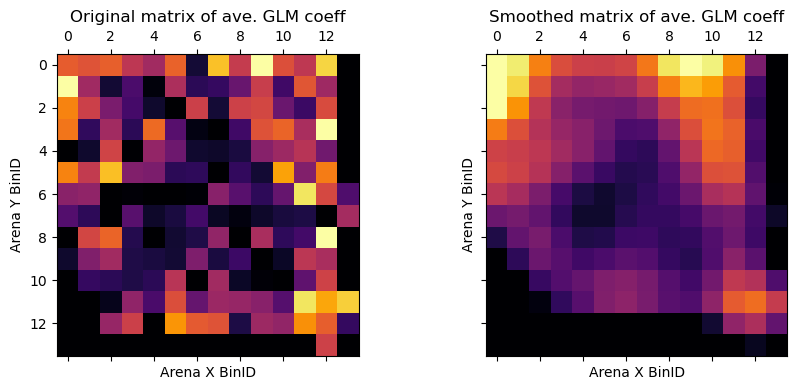

In [30]:
#heatmap of average GLM coeff magnitude per position bin overlayed on the arena, just for the position selection neurons (Good =1)

from scipy import sparse
from scipy.ndimage import gaussian_filter

# set nans to 0
AveInt = copy.deepcopy(AverageIntensity)
#masked_image = np.ma.masked_array(AveInt, np.isnan(AveInt))
# Apply Gaussian filter
#smoothed_matrix = gaussian_filter(masked_image, sigma=2)

AveInt[np.isnan(AveInt)] = np.nanmean(AveInt)

# smooth the matrix
smoothed_matrix = gaussian_filter(AveInt, sigma=1.1)

# Set 0s to None as they will be ignored when plotting
# smoothed_matrix[smoothed_matrix == 0] = None
AveInt[AveInt == np.nanmean(AveInt)] = math.nan

# Plot the data
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2,
                               sharex=False, sharey=True,
                               figsize=(9, 4))

if RunKey == 0:
    ax1.matshow(AverageIntensity,cmap='inferno', vmin=0.13, vmax=0.33)
    ax1.set_title("Original matrix of ave. GLM coeff")
    ax1.set_xlabel('Arena X BinID')
    ax1.set_ylabel('Arena Y BinID')
    ax2.matshow(smoothed_matrix,cmap='inferno', vmin=0.14, vmax=0.26)
    ax2.set_title("Smoothed matrix of ave. GLM coeff")
    ax2.set_xlabel('Arena X BinID')
    ax2.set_ylabel('Arena Y BinID')
    plt.tight_layout()
    plt.show()

if RunKey == 2:
    ax1.matshow(AverageIntensity,cmap='inferno', vmin=0.15, vmax=0.35)
    ax1.set_title("Original matrix of ave. GLM coeff")
    ax1.set_xlabel('Arena X BinID')
    ax1.set_ylabel('Arena Y BinID')
    ax2.matshow(smoothed_matrix,cmap='inferno', vmin=0.16, vmax=0.26)
    ax2.set_title("Smoothed matrix of ave. GLM coeff")
    ax2.set_xlabel('Arena X BinID')
    ax2.set_ylabel('Arena Y BinID')
    plt.tight_layout()
    plt.show()

In [25]:
df_coeffs = pd.DataFrame(index=range(num_bins_x*num_bins_y), columns=range(3))
df_coeffs.columns = ['X', 'Y','Z']

xx = np.linspace(1, 1, num_bins_x)
yy = np.linspace(1, 1, num_bins_y)
X, Y = np.meshgrid(xx, yy)

for i in range(num_bins_x):
    for j in range(num_bins_y):
        df_coeffs.loc[i*14+j, 'X'] = i
        df_coeffs.loc[i*14+j, 'Y'] = j
        df_coeffs.loc[i*14+j, 'Z'] = AverageIntensity[i,j]

dR = copy.deepcopy(GoodWeightdX)

for i in range(len(GoodWeightdX)):
    dR[i] = int(np.sqrt(GoodWeightdX[i]*GoodWeightdX[i] + GoodWeightdY[i]*GoodWeightdY[i]))

df_RvsCoeff = pd.DataFrame(index=range(len(GoodWeightList)), columns=range(2))
df_RvsCoeff.columns = ['dR', 'Coeff']

for j in range(len(GoodWeightList)):
        df_RvsCoeff.loc[j, 'dR'] = str(dR[j])
        df_RvsCoeff.loc[j, 'Coeff'] = GoodWeightListAbs[j]

df_RvsCoeff['dR'] = df_RvsCoeff['dR'].astype('category')
df_RvsCoeff['Coeff'] = df_RvsCoeff['Coeff'].astype('float')
#sns.boxplot(data=df_RvsCoeff, x="Coeff", y="dY",notch=True,showfliers=False,order=["-6.5", "-5.5","-4.5","-3.5","-2.5","-1.5","-0.5","0.5","1.5","2.5","3.5","4.5","5.5","6.5"])
#sns.boxplot(GoodWeightdY,GoodWeightList)

# Group data by the categorical column
categories = df_RvsCoeff['dR'].unique()
#boxplot_data = [df_RvsCoeff[df_RvsCoeff['dR'] == category]['Coeff'] for category in categories]

# Create the boxplot
#plt.boxplot(boxplot_data, labels=categories,showfliers=False,bootstrap=None, meanline=False, showmeans=True,whis=(25, 75),notch=True)
#plt.title('Boxplot by Category')
#plt.xlabel('Radial Distance from Origin (# of Bins)')
#plt.ylabel('GLM Position Selectivity Coeff.')
#plt.show()

#plt.boxplot(boxplot_data, labels=categories)
#plt.title('Boxplot by Category')
#plt.xlabel('Category')
#plt.ylabel('Values')
#plt.show()

C:\Users\ryanb\AppData\Local\Temp\ipykernel_84680\2435949030.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_RvsCoeff.groupby('dR')['Coeff'].agg(['mean', 'count', 'std'])
C:\Users\ryanb\AppData\Local\Temp\ipykernel_84680\2435949030.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(data=df_RvsCoeff, x='dR', y='Coeff', ci=None, color='blue', markers='o', linestyles='-',markersize=10)


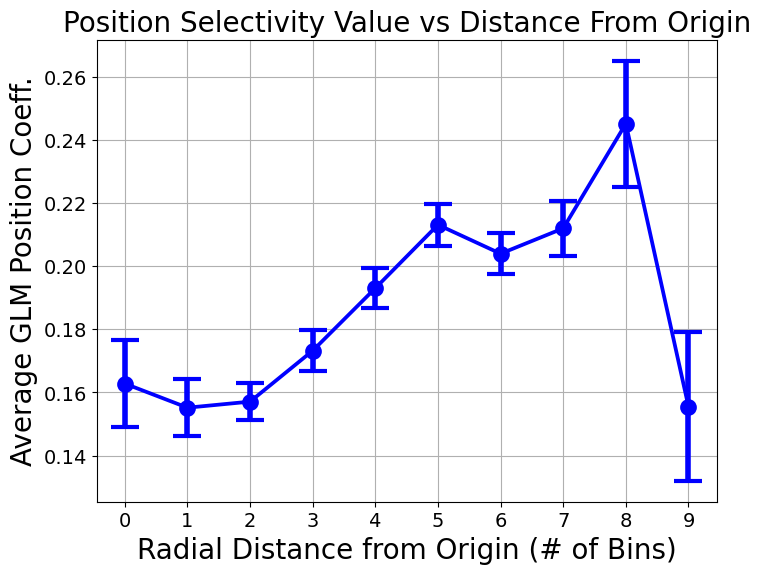

In [26]:
from scipy.stats import sem, t
# Calculate mean and 95% CI of GLM coeffs radially away from origin (48, 48) in original 96 x 96 arena
summary = df_RvsCoeff.groupby('dR')['Coeff'].agg(['mean', 'count', 'std'])
#print(summary)
confidence = 0.95
summary['sem'] = summary['std'] / np.sqrt(summary['count'])  # Standard error
summary['margin_of_error'] = summary['sem'] * t.ppf((1 + confidence) / 2, summary['count'] - 1)
summary['lower_ci'] = summary['mean'] - summary['margin_of_error']
summary['upper_ci'] = summary['mean'] + summary['margin_of_error']

# Plot
plt.figure(figsize=(8, 6))
sns.pointplot(data=df_RvsCoeff, x='dR', y='Coeff', ci=None, color='blue', markers='o', linestyles='-',markersize=10)
for i, row in summary.iterrows():
    plt.errorbar(x=i, y=row['mean'], yerr=row['margin_of_error'], fmt='o', color='blue', capsize=10,linewidth=4,elinewidth=4,markeredgewidth=3)

plt.title('Position Selectivity Value vs Distance From Origin',fontsize=20)
plt.ylabel('Average GLM Position Coeff.',fontsize=20)
plt.xlabel('Radial Distance from Origin (# of Bins)',fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(True)
plt.show()

In [27]:
# number of position-selective neurons in the GRU/LSTM
len(GoodIDList)

190

In [28]:

#GoodWeightList = []
#GoodWeightListAbs = []
#GoodWeightdX = []
#GoodWeightdY = 
#plt.scatter(dR,GoodWeightListAbs,s=5)
#plt.show()
#plt.scatter(GoodWeightdX,GoodWeightList,s=5)
#plt.show()
#plt.scatter(GoodWeightdY,GoodWeightList,s=5)
#plt.show()

In [29]:

#Z = np.sin(np.sqrt(X**2 + Y**2))


        